<a href="https://colab.research.google.com/github/mehdi-belhamiti/Hierarchical-Risk-Parity-Python/blob/main/Hierarchical_Risk_Parity_Python_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
import scipy.spatial.distance as ssd

In [13]:
# Sélection de 10 actifs pour le portfolio
tickers = ['SPY', 'TLT', 'GLD', 'VIXY', 'USO', 'VNQ', 'EEM', 'BTC-USD', 'UUP', 'FXY']

# Récupération des données des 5 dernieres années
data = yf.download(tickers, period="5y")['Close']

# calcul des rendements journaliers et en enlevant les valeurs manquantes
returns = data.pct_change().dropna()

corr_matrix = returns.corr()

#Matrice de distance pour le modèle HRP
#Formule : D = sqrt(0.5 * (1 - Corrélation))
distance_matrix = np.sqrt(np.clip(0.5 * (1 - corr_matrix), 0, 1))

print("\nDimensions des rendements :", returns.shape)

/tmp/ipykernel_4233/999782395.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="5y")['Close']
[*********************100%***********************]  10 of 10 completed


Dimensions des rendements : (1826, 10)



/tmp/ipykernel_4233/999782395.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


[0.5867725  0.69453149 0.66250247 0.55350226 0.70369761 0.69607991
 0.76467983 0.81449694 0.61298458 0.65723479 0.57040042 0.40183816
 0.67231136 0.69836177 0.84837461 0.88240673 0.53898255 0.57359467
 0.71517632 0.55840645 0.7325257  0.90531619 0.65692369 0.65430677
 0.65272689 0.62830434 0.66630357 0.8463249  0.72495044 0.64751299
 0.67617135 0.67808067 0.79591456 0.93812627 0.41455102 0.76644369
 0.79639862 0.70820636 0.59585786 0.70663928 0.72848607 0.69579986
 0.66004853 0.81444956 0.86772722]


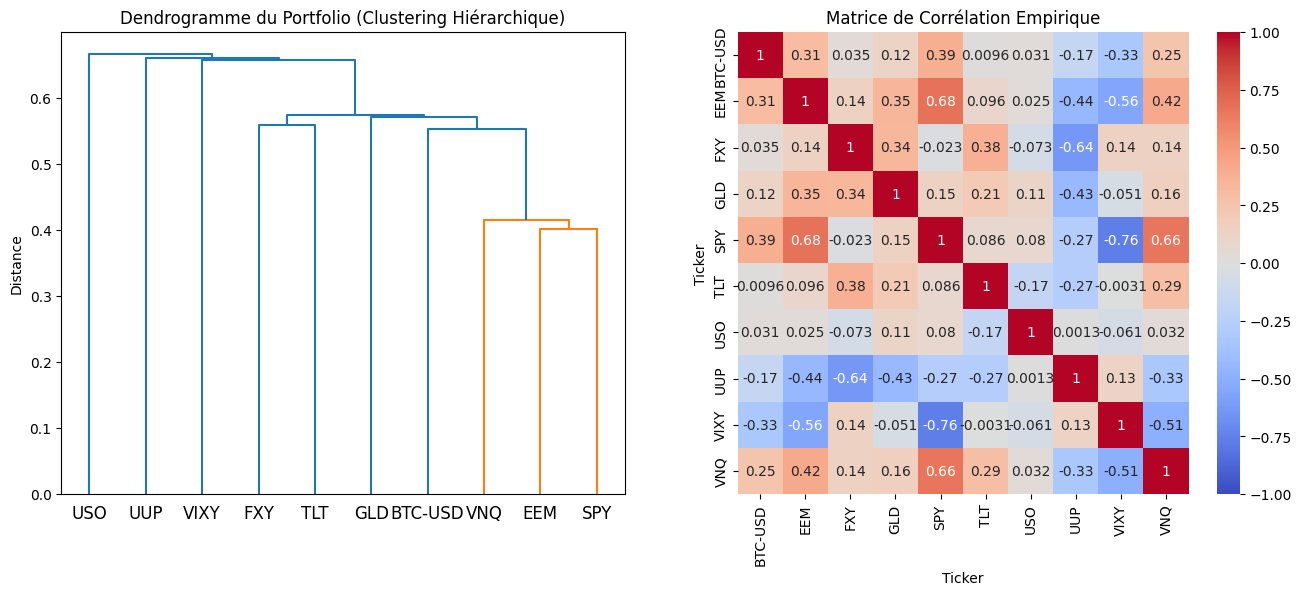

In [21]:
condensed_dist = ssd.squareform(distance_matrix)
print (condensed_dist)

# Clustering hiérarchique
Z = linkage(condensed_dist, method='single')

# visualisation : Dendrogramme et Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dendrogram(Z, labels=distance_matrix.columns, ax=axes[0])
axes[0].set_title("Dendrogramme du Portfolio (Clustering Hiérarchique)")
axes[0].set_ylabel("Distance")

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns,
            ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Matrice de Corrélation Empirique")
plt.show()